In [12]:
import numpy as np
import matplotlib.pyplot as plt


import torch
from torch import nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torch.nn import functional as F
from torch.optim import AdamW

In [14]:
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert PIL Image to PyTorch Tensor (scales pixels to 0-1)
    #transforms.Normalize((0.1307,), (0.3081,))  # Normalize with MNIST global mean and std
])

# 2. Import and download the Training Dataset
train_dataset = torchvision.datasets.MNIST(
    root='./data',       # Directory where data will be stored
    train=True,          # Load the 60,000 training images
    download=True,       # Download from the internet if not present locally
    transform=transform  # Apply the defined preprocessing
)

# 3. Import and download the Test Dataset
test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,         # Load the 10,000 test images
    download=True,
    transform=transform
)

# 4. Wrap datasets in DataLoaders for batch processing and shuffling
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=1, shuffle=False)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"目前使用的裝置: {device}")


目前使用的裝置: cuda


In [4]:
for idx, (data, _) in enumerate(train_loader):
    print(data)
    break

tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        ...,


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0.

In [10]:
class VAE(nn.Module):

    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super().__init__()

        # Encoder
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder
        self.fc2 = nn.Linear(latent_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        logvar = torch.clamp(logvar, min=-20.0, max=20.0)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + (eps * std)

    def decode(self, z):
        h = F.relu(self.fc2(z))
        return F.sigmoid(self.fc3(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstruction = self.decode(z)
        return reconstruction, mu, logvar

def vae_loss(recon_x, x, mu, logvar, kl_weight):
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction="sum")
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    total_loss = recon_loss + (kl_weight * kl_loss)
    return total_loss, recon_loss, kl_loss


VAE_model = VAE().to(device)
optimizer = AdamW(VAE_model.parameters(), lr=0.001)

epochs = 10

for epoch in range(epochs):
    VAE_model.train()
    total_VAEloss = 0
    total_recon_loss = 0
    total_kl_loss = 0

    kl_weight = min(1.0, epoch / 50.0) * 0.1

    for batch in train_loader:
        batch_data = batch[0].view(batch[0].size(0), -1).float().to(device)

        optimizer.zero_grad()
        recon, mu, logvar = VAE_model(batch_data)
        VAEloss, recon_loss, kl_loss = vae_loss(recon, batch_data, mu, logvar, kl_weight)

        VAEloss.backward()
        optimizer.step()

        num_batches = len(train_loader)
        total_VAEloss += VAEloss.item() / num_batches
        total_recon_loss += recon_loss.item() / num_batches
        total_kl_loss += kl_loss.item() / num_batches

    total_samples = len(train_dataset)
    avg_loss = total_VAEloss / total_samples
    avg_recon_loss = total_recon_loss / total_samples
    avg_kl_loss = total_kl_loss / total_samples

    if (epoch + 1) or epoch == 0:
        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {avg_loss:.4f} | "
            f"Recon: {avg_recon_loss:.4f} | "
            f"KL: {avg_kl_loss:.4f} (wt: {kl_weight:.3f})"
        )


Epoch [1/10] Loss: 0.1186 | Recon: 0.1186 | KL: 0.2259 (wt: 0.000)
Epoch [2/10] Loss: 0.0821 | Recon: 0.0816 | KL: 0.2409 (wt: 0.002)
Epoch [3/10] Loss: 0.0781 | Recon: 0.0773 | KL: 0.2045 (wt: 0.004)
Epoch [4/10] Loss: 0.0763 | Recon: 0.0752 | KL: 0.1748 (wt: 0.006)
Epoch [5/10] Loss: 0.0751 | Recon: 0.0739 | KL: 0.1515 (wt: 0.008)
Epoch [6/10] Loss: 0.0743 | Recon: 0.0730 | KL: 0.1345 (wt: 0.010)
Epoch [7/10] Loss: 0.0738 | Recon: 0.0723 | KL: 0.1219 (wt: 0.012)
Epoch [8/10] Loss: 0.0734 | Recon: 0.0718 | KL: 0.1123 (wt: 0.014)
Epoch [9/10] Loss: 0.0730 | Recon: 0.0714 | KL: 0.1048 (wt: 0.016)
Epoch [10/10] Loss: 0.0728 | Recon: 0.0710 | KL: 0.0991 (wt: 0.018)


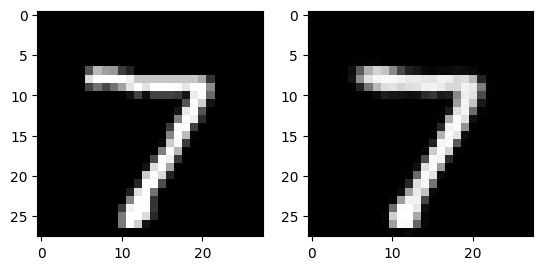

In [46]:
for idx, (data, label) in enumerate(test_loader):
  data = data.view(data.size(0), -1).float().to(device)
  recon_vector, mu, logvar = VAE_model(data)
  data_vector = data.reshape(-1, 1, 28, 28).cpu().detach().numpy()
  recon_vector = recon_vector.reshape(-1, 1, 28, 28).cpu().detach().numpy()
  original_img = data_vector.reshape(28, 28)
  recon_img = recon_vector.reshape(28, 28)
  plt.subplot(1, 2, 1)
  plt.imshow(original_img, cmap='gray')
  plt.subplot(1, 2, 2)
  plt.imshow(recon_img, cmap='gray')
  plt.show()
  if idx == 0:
    break

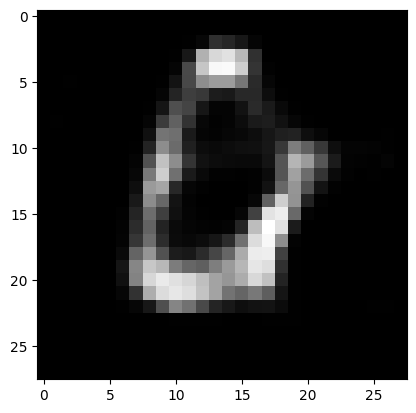

In [59]:
z = torch.randn(1, 20).to(device)
VAE_model.eval()
with torch.no_grad():
  recon_vector = VAE_model.decode(z).cpu().detach().numpy()
  recon_img = recon_vector.reshape(28, 28)
  plt.imshow(recon_img, cmap='gray')
  plt.show()

/tmp/ipykernel_2510/3939781595.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  z_interp = torch.tensor(z_interp, dtype=torch.float32)


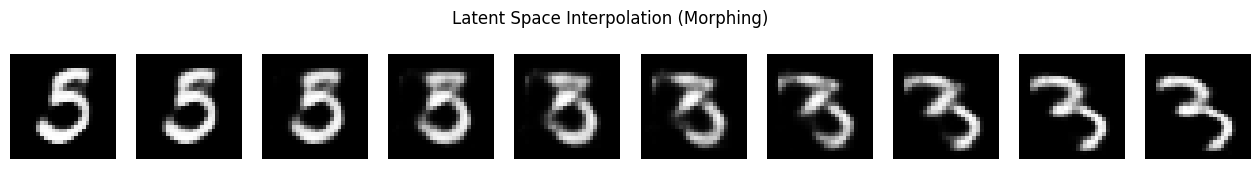

In [89]:
test_loader = DataLoader(dataset=test_dataset, batch_size=2, shuffle=True)
VAE_model.eval()
with torch.no_grad():
  for data, _ in test_loader:
    data_1 = data[0].view(1, -1).float().to(device)
    data_2 = data[1].view(1, -1).float().to(device)
    mu_1, _ = VAE_model.encode(data_1)
    mu_2, _ = VAE_model.encode(data_2)
    break


# 2. 設定中間點的數量 (例如 8 個步驟)
steps = 10
alphas = torch.linspace(0, 1, steps)

plt.figure(figsize=(16, 2))
for i, alpha in enumerate(alphas):
    # 線性插值公式：(1 - alpha) * z1 + alpha * z2
    z_interp = (1 - alpha) * mu_1 + (alpha * mu_2)
    with torch.no_grad():
      z_interp = torch.tensor(z_interp, dtype=torch.float32)
      recon_vector = VAE_model.decode(z_interp).cpu().detach().numpy()
      recon_vector = recon_vector.reshape(28, 28)


    plt.subplot(1, steps, i + 1)
    plt.imshow(recon_vector, cmap='gray')
    plt.axis('off')

plt.suptitle("Latent Space Interpolation (Morphing)")
plt.show()

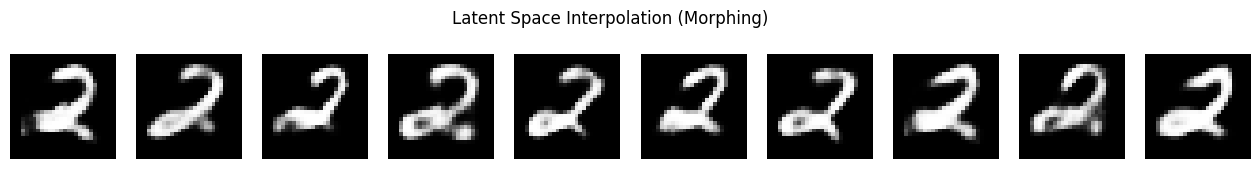

In [110]:
VAE_model.eval()
test_loader = DataLoader(dataset=test_dataset, batch_size=1, shuffle=True)
with torch.no_grad():
  for data, _ in test_loader:
    data = data.view(1, -1).float().to(device)
    mu, logvar = VAE_model.encode(data)
    mu = mu.detach()
    break
steps = 10
plt.figure(figsize=(16, 2))
alphas = torch.linspace(0, 1, steps)
with torch.no_grad():
  for i in range(steps):
    noise = torch.randn(1,20).to(device)
    new_data = mu + noise
    img_vector = VAE_model.decode(new_data).to(device)
    img_vector = img_vector.reshape(28, 28).cpu().detach().numpy()

    plt.subplot(1, steps, i + 1)
    plt.imshow(img_vector, cmap='gray')
    plt.axis('off')

plt.suptitle("Latent Space Interpolation (Morphing)")
plt.show()


In [150]:
from getpass import getpass

# 1. 取得新 Token (執行後會跳出輸入框)
token = getpass("get token")

# 2. 設定 Remote URL (使用 f-string 填入變數)
repo_url = f"https://{token}/@github.com/Iittlefish/MNIST-with-VAE"
!git remote set-url origin {repo_url}

print("Remote URL 已更新！")

get token··········
Remote URL 已更新！


In [194]:
# 1. 掛載 Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
[Errno 2] No such file or directory: '/content/drive/MyDrive/Colab NoteBook/'
/content


In [202]:
%cd /content/drive/MyDrive/Colab_Notebooks/MNIST_with_VAE

!git init
!git add .
!git commit -m "feat: VAE generate digits"

!git push -u origin main

/content/drive/MyDrive/Colab_Notebooks/MNIST_with_VAE
hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/drive/MyDrive/Colab_Notebooks/MNIST_with_VAE/.git/
[master (root-commit) 6502850] feat: VAE generate digits
 1 file changed, 1 insertion(+)
 create mode 100644 MNIST with VAE.ipynb
error: src refspec main does not match any
error: failed to push some refs to 'origin'
